# Haplosaurus

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/grid/koo/home/schilder/projects/GenomeEncoder/')
import pandas as pd
import sys
sys.path.append("code")
import src.haplosaurus as hs
import src.variant_annotation as va
import src.ESM as ESM
import src.onekg as onekg
import src.utils as utils
import src.proteingym as pg

In [14]:
# %%R

# db = EnsDb.Hsapiens.v86::EnsDb.Hsapiens.v86
# # get the transcript to protein ID mappings
# txs <- GenomicFeatures::transcripts(db, columns = c("tx_id","protein_id"))
# txs <- txs[!is.na(txs$protein_id)]
# data.table::fwrite(data.frame(txs), "data/bioc/bioc_tx_to_prot.csv.gz")

## Get transcripts

In [15]:
# hs_db = hs.get_figshare("haplotype_analysis_database.zip")
# #  List all files in the directory
# hs_db_files = [f"{hs_db}/{x}" for x in os.listdir(hs_db)]
# hs_db_sql = [x for x in hs_db_files if x.endswith(".sql.gz")][0]
# hs_db_files
# import mysql.connector
# conn = mysql.connector.connect(
# host="localhost",
# user="root",
# password="root",
# database="haplotype_analysis_database"
# )
# cursor = conn.cursor() 

In [2]:
# Haplosaurus protein IDs
tx_df = pd.read_excel("data/haplosaurus/41467_2018_6542_MOESM4_ESM.xlsx")
print(tx_df.shape)
# Bioconductor transcript to protein ID
tx_to_prot = pd.read_csv("data/bioc/bioc_tx_to_prot.csv.gz")
print(tx_to_prot.shape)
tx_df = tx_df.merge(tx_to_prot.drop_duplicates(subset=['tx_id', 'protein_id']),
                    left_on="Ensembl Protein ID", 
                    right_on="protein_id", 
                    how="inner") 
print(tx_df.shape)
tx_df.head()

(20166, 6)
(109705, 9)
(18494, 15)


/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3098: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Ensembl Gene ID,Ensembl Protein ID,Gene Name,Number of Haplotypes,Number of Haplotypes FoO>=1%,Frequency Rank of Reference Protein Haplotype,seqnames,start,end,width,strand,protein_id,uniprot_id,tx_biotype,tx_id
0,ENSG00000121410,ENSP00000263100,A1BG,44,3.0,2.0,19,58346850,58353499,6650,-,ENSP00000263100,P04217,protein_coding,ENST00000263100
1,ENSG00000148584,ENSP00000363107,A1CF,25,2.0,1.0,10,50806562,50885675,79114,-,ENSP00000363107,Q9NQ94,protein_coding,ENST00000373995
2,ENSG00000175899,ENSP00000323929,A2M,69,5.0,10.0,12,9067712,9116157,48446,-,ENSP00000323929,P01023,protein_coding,ENST00000318602
3,ENSG00000166535,ENSP00000299698,A2ML1,171,9.0,10.0,12,8822472,8876785,54314,+,ENSP00000299698,A8K2U0,protein_coding,ENST00000299698
4,ENSG00000184389,ENSP00000475261,A3GALT2,34,1.0,1.0,1,33306766,33321098,14333,-,ENSP00000475261,U3KPV4,protein_coding,ENST00000442999


<AxesSubplot:>

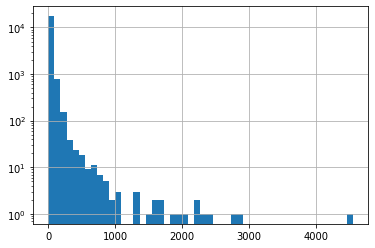

In [3]:
tx_df['Number of Haplotypes'].hist(bins=50, log=True)

In [4]:
# Remove MUC genes with lots of haplotypes as these may be artifacts
# tx_df = tx_df[(tx_df['Number of Haplotypes'] > 50) & (tx_df['Number of Haplotypes'] < 1000)]
# tx_df['Gene Name'].str.startswith('MUC')
tx_df.sort_values('Number of Haplotypes', ascending=False)
tx_ids = list(set(tx_df['tx_id'].tolist()))
tx_ids.reverse() # Start with the smallest number of haplotypes
# tx_ids = tx_ids[:5]

print(len(tx_ids),"transcripts")

18494 transcripts


## Get variant sets
Collect sets of vairants (pathogenic, benign, 1KG) for each transcripts. 
Only trancripts with at least one pathogenic variant and one benign variant of the specifiied consequence type are included. Pathogenic/benign variants present in the 1KG cohort are excluded.

### Missense

In [22]:
variant_sets_dict = {
    ('SO:0001583','missense_variant'):{},
    ('SO:0001589','frameshift_variant'):{},
    ('SO:0001906','feature_truncation'):{}
    }

In [ ]:
for so_term, consequence_type in variant_sets_dict.keys():
    print(so_term, consequence_type)
    # cache_only = consequence_type == "missense_variant"
    # Gather variant sets
    variant_sets_dict[(so_term, consequence_type)] = hs.get_variant_sets(
        tx_ids = tx_ids,
        so_term = so_term,
        consequence_type = consequence_type,
        # cache_only = cache_only, # Use cached files only (faster)
        error=False,
        # force=True
        )


SO:0001589 frameshift_variant


Gathering variant sets:   0%|          | 0/18494 [00:00<?, ?it/s]

Error getting variant sets for ENST00000519561: Server returned HTTP status code: 400
Content: {'error': "ID 'ENST00000519561' not found"}


Filtering variants:   0%|          | 0/3 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/8 [00:00<?, ?it/s]

...

Filtering variants:   0%|          | 0/1 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/65 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/2 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/2 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/69 [00:00<?, ?it/s]

In [21]:
# Get the number of transcripts with variant sets per consequence type
{k:len(v) for k,v in variant_sets_dict.items()}

{('SO:0001583', 'missense_variant'): 1070,
 ('SO:0001589', 'frameshift_variant'): 0,
 ('SO:0001906', 'feature_truncation'): 0}

## Get haplotypes


In [14]:
haplotypes = hs.get_haplotypes(
    tx_ids=tx_ids, #variant_sets.keys(),
    save_dir="data/haplosaurus/haplotypes",
    species="homo_sapiens",
    params={'samples':1,
            'sequence':1,
            'aligned_sequences':1},
    cache_only=True, # Use cached files only (faster)
    force=False
    )


Getting haplotypes:   0%|          | 0/3380 [00:00<?, ?it/s]

## Get reference haplotypes

In [15]:
haplotypes_ref = hs.get_haplotype_ref(haplotypes)
haplotypes_ref_seqs, missing_seqs = hs.get_haplotype_seqs(
    haplotypes_ref,
    return_missing=True,
    verbose=True)
(len(haplotypes), 
 len(haplotypes_ref), 
 len(haplotypes_ref_seqs),
 len(missing_seqs))


Processing transcripts:   0%|          | 0/402 [00:00<?, ?it/s]

  0%|          | 0/402 [00:00<?, ?it/s]

No seqs found for ENST00000359568
No seqs found for ENST00000324093
No seqs found for ENST00000405460
No seqs found for ENST00000354785


(402, 402, 398, 4)

## Add variants to haplotypes

In [16]:
haplotypes_wt, haplotypes_pathogenic, haplotypes_benign = hs.add_variant_to_haplotypes(
  haplotypes=haplotypes, 
  variant_sets=variant_sets, 
  tx_ids=tx_ids,
  consequence_terms=['missense_variant'],
  max_transcripts=5,
  ref_checks=False,
  verbose=True
  )
# check length of each group
len(haplotypes_wt), len(haplotypes_pathogenic), len(haplotypes_benign)

Adding variants to transcript haplotypes:   0%|          | 0/5 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/1 [00:00<?, ?it/s]

Getting pathogenic variant VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Filtering variants VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding pathogenic variants to haplotypes:   0%|          | 0/122 [00:00<?, ?it/s]

...

Filtering variants:   0%|          | 0/8 [00:00<?, ?it/s]

Getting benign variant VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Filtering variants VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding benign variants to haplotypes:   0%|          | 0/57 [00:00<?, ?it/s]

(5, 5, 5)

In [17]:
print(hs.get_haplotype_counts(haplotypes_wt))
print(hs.get_haplotype_counts(haplotypes_pathogenic))
print(hs.get_haplotype_counts(haplotypes_benign))


{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}


## ESM

In [18]:
# Check if GPU available
try:
    import torch
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.cuda.current_device())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
except:
    print("No GPU available")

False
0
No GPU available


### Get embeddings

#### Prepare batches

In [38]:
batches = hs.haplotypes_to_batches_grouped(
    haplotypes_grouped = {'WT':haplotypes_wt, 
                          'Pathogenic':haplotypes_pathogenic, 
                          'Benign':haplotypes_benign
                         }
)

Preparing batches for ESM


Preparing batches:   0%|          | 0/5 [00:00<?, ?it/s]

Preparing batches for ESM


Preparing batches:   0%|          | 0/5 [00:00<?, ?it/s]

Preparing batches for ESM


Preparing batches:   0%|          | 0/5 [00:00<?, ?it/s]

In [79]:
batch_info = ESM.check_batch_info(batches)

                 size  groups  size_per_group  remainder  haplotype_count
ENST00000396946   225       3              75          0               75
ENST00000338034   162       3              54          0               54
ENST00000369850    21       3               7          0                7


### Generate embeddings

In [134]:
## UNGROUPED

esm_results = ESM.get_embeddings(
    batches, 
    save_dir=f"data/1KG/embeddings/esm2_t33_650M_UR50D",
    # tx_suffix_dict=tx_suffix_dict,
    error=True,
    verbose=True
#         force=True
    )

Using model: esm2_t33_650M_UR50D


Embedding transcript proteoforms:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
## GROUPED

# haplotypes_grouped = {'WT':haplotypes_wt, 
#                      'Pathogenic':haplotypes_pathogenic, 
#                      'Benign':haplotypes_benign
#                      }
# batches_grouped = {}
# embeddings_grouped = {}
# for group, haplotypes_group in haplotypes_grouped.items():
#     # Get batches
#     batches_grouped[group] = hs.haplotypes_to_batches(
#         haplotypes_group,
#         suffix=''
#         )
#     # Get embeddings
#     embeddings_grouped[group] = ESM.get_embeddings(
#         batches_grouped[group], 
#         save_dir=f"data/1KG/embeddings/esm2_t33_650M_UR50D/{group}",
#         desc=f"Embedding {group} transcript proteoforms",
#         error=True,
#         verbose=True
# #         force=True
#         )

### Reconstruct data from saved files

####  *** Find save paths of precomputed embeddings

In [2]:
save_paths = ESM.list_embeddings(f"data/1KG/embeddings/esm2_t33_650M_UR50D")
save_paths

{'ENST00000369850': 'data/1KG/embeddings/esm2_t33_650M_UR50D/ENST00000369850.pkl',
 'ENST00000396946': 'data/1KG/embeddings/esm2_t33_650M_UR50D/ENST00000396946.pkl',
 'ENST00000338034': 'data/1KG/embeddings/esm2_t33_650M_UR50D/ENST00000338034.pkl'}

#### Recreate the data from files

In [3]:
# Recreate the data from files
(haplotypes,
 haplotypes_grouped, 
 variant_sets, 
 batches)  = hs.reconstruct_data(save_paths.keys())


Getting haplotypes:   0%|          | 0/3 [00:00<?, ?it/s]

Gathering variant sets:   0%|          | 0/3 [00:00<?, ?it/s]

ENST00000369850: Annotating pathogenic variants:   0%|          | 0/17 [00:00<?, ?it/s]

ENST00000369850: Filtering pathogenic variants:   0%|          | 0/17 [00:00<?, ?it/s]

ENST00000369850: Annotating benign variants:   0%|          | 0/83 [00:00<?, ?it/s]

...

Filtering variants VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding benign variants to haplotypes:   0%|          | 0/75 [00:00<?, ?it/s]

Preparing batches:   0%|          | 0/3 [00:00<?, ?it/s]

Preparing batches:   0%|          | 0/3 [00:00<?, ?it/s]

Preparing batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [4]:
batch_info = ESM.check_batch_info(batches)

                 size  groups  size_per_group  remainder  haplotype_count
ENST00000369850    21       3               7          0                7
ENST00000338034   162       3              54          0               54
ENST00000396946   225       3              75          0               75


In [5]:
## From save paths
seq_reps = ESM.get_representations(
        batches=batches, 
        tx_ids='ENST00000396946',#list(save_paths.keys())[-1],
        save_paths=list(save_paths.values())
        )

## From in-memory embeddings
# seq_reps = ESM.get_representations(
#         batches=batches, 
#         tx_ids=list(batches.keys())[2],
#         esm_results=esm_results['results'],
#         )

Found 3 ESM-2 embeddingfiles


Extracting sequence representations:   0%|          | 0/3 [00:00<?, ?it/s]

Loading 'data/1KG/embeddings/esm2_t33_650M_UR50D/ENST00000396946.pkl': 100%|██████████| 1.37G/1.37G [00:00<00:00, 1.92GB/s]


> ENST00000396946 : 225 sequence representations extracted.
TOTAL: 225 sequence representations extracted across 1 transcript(s).


In [6]:
print(len(seq_reps))
seq_reps[:10]

225


[('ENSP00000380150:REF_WT:',
  tensor([ 0.0277, -0.0050,  0.0230,  ..., -0.0256,  0.0607,  0.0510])),
 ('ENSP00000380150:530E>D_WT:',
  tensor([ 0.0269, -0.0045,  0.0231,  ..., -0.0262,  0.0614,  0.0513])),
 ('ENSP00000380150:581A>T_WT:',
  tensor([ 0.0287, -0.0057,  0.0233,  ..., -0.0253,  0.0610,  0.0503])),
 ('ENSP00000380150:1009V>I_WT:',
  tensor([ 0.0280, -0.0047,  0.0226,  ..., -0.0257,  0.0608,  0.0507])),
 ('ENSP00000380150:748T>A_WT:',
  tensor([ 0.0272, -0.0049,  0.0228,  ..., -0.0259,  0.0606,  0.0518])),
 ('ENSP00000380150:1152D>N_WT:',
  tensor([ 0.0276, -0.0053,  0.0230,  ..., -0.0262,  0.0602,  0.0504])),
 ('ENSP00000380150:527H>Q,537S>T_WT:',
  tensor([ 0.0284, -0.0048,  0.0231,  ..., -0.0253,  0.0602,  0.0520])),
 ('ENSP00000380150:6P>T_WT:',
  tensor([ 0.0281, -0.0054,  0.0233,  ..., -0.0253,  0.0604,  0.0513])),
 ('ENSP00000380150:881S>G_WT:',
  tensor([ 0.0273, -0.0053,  0.0227,  ..., -0.0252,  0.0608,  0.0514])),
 ('ENSP00000380150:1020T>M_WT:',
  tensor([ 0.0282,

### Get sequence representation variances

In [7]:
variances_by_tx= ESM.get_representation_variances(seq_reps,
                                                  groups=['WT','Pathogenic','Benign'])

variances_by_tx

Computing transcript variances for WT:   0%|          | 0/1 [00:00<?, ?it/s]

Computing transcript variances for Pathogenic:   0%|          | 0/1 [00:00<?, ?it/s]

Computing transcript variances for Benign:   0%|          | 0/1 [00:00<?, ?it/s]

{'ENSP00000380150': {'WT': (tensor([3.4676e-07, 1.4905e-07, 1.5560e-07,  ..., 2.6242e-07, 1.7398e-07,
           3.5093e-07]),
   tensor(3.1044e-07)),
  'Pathogenic': (tensor([3.4746e-07, 1.4950e-07, 1.5309e-07,  ..., 2.6300e-07, 1.7678e-07,
           3.4960e-07]),
   tensor(3.0917e-07)),
  'Benign': (tensor([3.4393e-07, 1.4906e-07, 1.5434e-07,  ..., 2.6557e-07, 1.7128e-07,
           3.4243e-07]),
   tensor(3.1023e-07))}}

### Get UMAP

In [8]:
X = ESM.get_representation_matrix(seq_reps)

torch.Size([225, 1280])


In [9]:
umap_model, embedding, nan_indices = utils.run_umap(X)
# tsvd_model, embedding, nan_indices = utils.run_tsvd(X)
# ica_model, embedding, nan_indices = utils.run_ica(X)
# rpca_model, embedding, nan_indices = utils.run_rpca(X)

Filtering matrix
Matrix shape before filtering: torch.Size([225, 1280])
Matrix shape after filtering: torch.Size([225, 1280])
Running UMAP


/grid/koo/home/schilder/.local/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Tue Jan 28 17:01:19 2025 Construct fuzzy simplicial set
Tue Jan 28 17:01:20 2025 Finding Nearest Neighbors
Tue Jan 28 17:01:22 2025 Finished Nearest Neighbor Search
Tue Jan 28 17:01:24 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Jan 28 17:01:25 2025 Finished embedding


#### Get embeddings dataframe with annotations

In [10]:
reduce_df = ESM.get_reduction_df(seq_reps=seq_reps, 
                                  haplotypes=haplotypes,
                                  embedding=embedding, 
                                  add_freqs=True,
                                  nan_indices=nan_indices) 
reduce_df.head()


Adding tx_id column


Getting haplotype frequencies:   0%|          | 0/3 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations


Adding haplotype frequencies:   0%|          | 0/32 [00:00<?, ?it/s]

{'GBR': 'EUR', 'FIN': 'EUR', 'CHS': 'EAS', 'PUR': 'AMR', 'CDX': 'EAS', 'CLM': 'AMR', 'IBS': 'EUR', 'PEL': 'AMR', 'PJL': 'SAS', 'KHV': 'EAS', 'ACB': 'AFR', 'GWD': 'AFR', 'ESN': 'AFR', 'BEB': 'SAS', 'MSL': 'AFR', 'STU': 'SAS', 'ITU': 'SAS', 'CEU': 'EUR', 'YRI': 'AFR', 'CHB': 'EAS', 'JPT': 'EAS', 'LWK': 'AFR', 'ASW': 'AFR', 'MXL': 'AMR', 'TSI': 'EUR', 'GIH': 'SAS'}


,UMAP 1,UMAP 2,label,label_base,edits,group,protein_id,tx_id,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,...,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:YRI,top_pop,top_superpop
0,13.069765,12.069993,ENSP00000380150:REF_WT:,ENSP00000380150:REF,0,WT:,ENSP00000380150,ENST00000396946,0.859375,0.843419,...,1.0,0.976471,0.984375,0.966346,0.964213,0.941176,0.971963,0.847222,GBR,EUR
1,13.422309,10.675999,ENSP00000380150:530E>D_WT:,ENSP00000380150:530E>D,1,WT:,ENSP00000380150,ENST00000396946,0.104167,0.100605,...,NaN,NaN,NaN,0.014423,NaN,NaN,NaN,0.106481,ESN,AFR
2,11.864754,12.633067,ENSP00000380150:581A>T_WT:,ENSP00000380150:581A>T,1,WT:,ENSP00000380150,ENST00000396946,NaN,0.000756,...,NaN,NaN,NaN,NaN,0.002045,NaN,NaN,NaN,KHV,EAS
3,12.643903,12.330434,ENSP00000380150:1009V>I_WT:,ENSP00000380150:1009V>I,1,WT:,ENSP00000380150,ENST00000396946,0.010417,0.009834,...,NaN,0.005882,NaN,NaN,NaN,NaN,NaN,0.004630,MSL,AFR
4,13.236314,11.849477,ENSP00000380150:748T>A_WT:,ENSP00000380150:748T>A,1,WT:,ENSP00000380150,ENST00000396946,NaN,NaN,...,NaN,NaN,0.010417,NaN,0.016360,0.039216,NaN,NaN,STU,SAS


In [11]:

reduce_df.value_counts('edits')

edits
1    201
2     21
0      3
dtype: int64

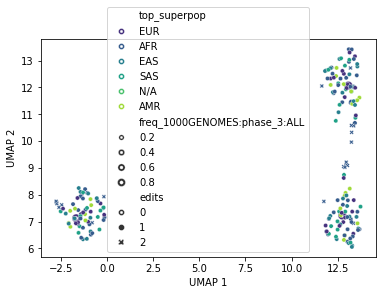

In [12]:
# plot the UMAP with the shapes
import seaborn as sns
import matplotlib.pyplot as plt
marker_map = utils.get_marker_map()
g = sns.scatterplot(data=reduce_df, 
                x='UMAP 1', 
                y='UMAP 2', 
                hue='top_superpop',
                style='edits',
                markers=marker_map,
                size='freq_1000GENOMES:phase_3:ALL',
                palette='viridis')
plt.show()


In [13]:
print(reduce_df.value_counts('top_superpop'))
print()
print(reduce_df.value_counts('top_pop'))


top_superpop
AFR    75
EAS    39
EUR    36
SAS    30
AMR    24
N/A    21
dtype: int64

top_pop
GWD    21
ESN    18
LWK    18
CEU    15
TSI    12
STU    12
KHV     9
PUR     9
PEL     9
ASW     9
CHS     9
CHB     9
GIH     6
BEB     6
ITU     6
JPT     6
CLM     6
CDX     6
YRI     6
IBS     3
GBR     3
FIN     3
MSL     3
dtype: int64


In [14]:
reduce_df = hs.add_genesymbol(reduce_df)
reduce_df.head()

,UMAP 1,UMAP 2,label,label_base,edits,group,protein_id,tx_id,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,...,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:YRI,top_pop,top_superpop,gene_id,gene_symbol
0,13.069765,12.069993,ENSP00000380150:REF_WT:,ENSP00000380150:REF,0,WT:,ENSP00000380150,ENST00000396946,0.859375,0.843419,...,0.984375,0.966346,0.964213,0.941176,0.971963,0.847222,GBR,EUR,ENSG00000198286,CARD11
1,13.422309,10.675999,ENSP00000380150:530E>D_WT:,ENSP00000380150:530E>D,1,WT:,ENSP00000380150,ENST00000396946,0.104167,0.100605,...,NaN,0.014423,NaN,NaN,NaN,0.106481,ESN,AFR,ENSG00000198286,CARD11
2,11.864754,12.633067,ENSP00000380150:581A>T_WT:,ENSP00000380150:581A>T,1,WT:,ENSP00000380150,ENST00000396946,NaN,0.000756,...,NaN,NaN,0.002045,NaN,NaN,NaN,KHV,EAS,ENSG00000198286,CARD11
3,12.643903,12.330434,ENSP00000380150:1009V>I_WT:,ENSP00000380150:1009V>I,1,WT:,ENSP00000380150,ENST00000396946,0.010417,0.009834,...,NaN,NaN,NaN,NaN,NaN,0.004630,MSL,AFR,ENSG00000198286,CARD11
4,13.236314,11.849477,ENSP00000380150:748T>A_WT:,ENSP00000380150:748T>A,1,WT:,ENSP00000380150,ENST00000396946,NaN,NaN,...,0.010417,NaN,0.016360,0.039216,NaN,NaN,STU,SAS,ENSG00000198286,CARD11


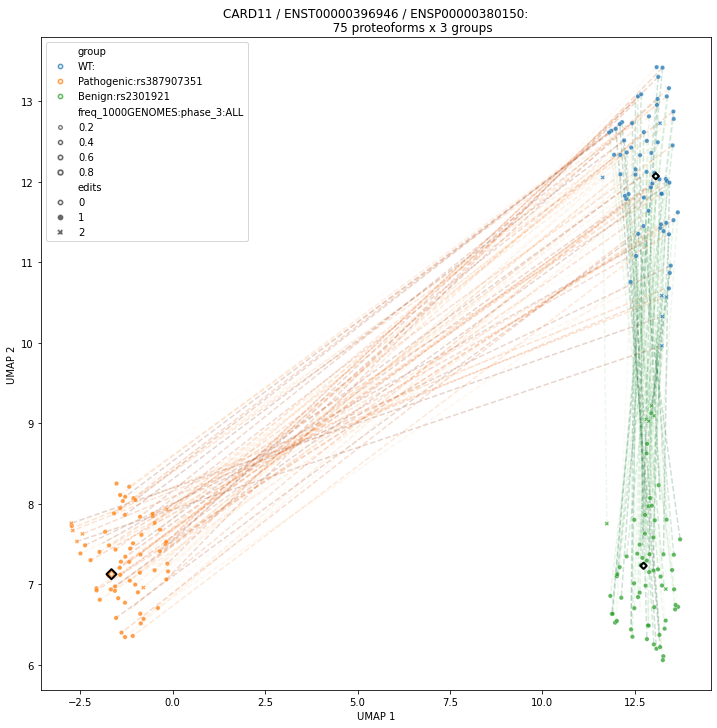

In [15]:
ESM.plot_umap(reduce_df,
        #   facet_col="transcript_id",
          title=f"{reduce_df['gene_symbol'][0]} / {reduce_df['tx_id'][0]} / {reduce_df['protein_id'][0]}:\n \
                  {reduce_df.label_base.nunique()} proteoforms x {reduce_df['group'].nunique()} groups",
          highlight_label="REF",
          opacity=.75,
          size="freq_1000GENOMES:phase_3:ALL",
          sizes=(20,50),
          style_col="edits",
          color_col="group",
          add_density=False,
          add_edges=True,
          show=True
        #   show_density=False,
#           bw_adjust=0.5, # Decrease bandwidth for higher granularity 
          # levels=20, # Increase number of contour levels
          # thresh=0.05 # Lower threshold to show more detail
          ) 

### Compute distances

In [16]:
dist_wt_vs_p = ESM.get_paired_distances(seq_reps, 
                                         group1="_WT", 
                                         group2="_Pathogenic",
                                         by_edits=True) 
dist_wt_vs_b = ESM.get_paired_distances(seq_reps,  
                                         group1="_WT", 
                                         group2="_Benign",
                                         by_edits=True)
dist_df = pd.concat([dist_wt_vs_p, dist_wt_vs_b], axis=0).sort_values('comparison')
dist_df.head()

Processing 1 edits
Found 204 sequences
Processing 2 edits
Found 24 sequences
Processing 1 edits
Found 204 sequences
Processing 2 edits
Found 24 sequences


,sample1,sample2,comparison,distance,haplotype,group1,group2,variants,protein_id,sample1_edits,sample2_edits,max_edits,edits_group
7,"ENSP00000380150:530E>D,669T>M_WT:","ENSP00000380150:530E>D,669T>M_Benign:rs2301921",WT_vs_Benign,0.659002,"ENSP00000380150:530E>D,669T>M",WT:,Benign:rs2301921,rs2301921,ENSP00000380150,2,2,2,2
20,ENSP00000380150:544I>L_WT:,ENSP00000380150:544I>L_Benign:rs2301921,WT_vs_Benign,0.660211,ENSP00000380150:544I>L,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,1,1,1
21,ENSP00000380150:967R>H_WT:,ENSP00000380150:967R>H_Benign:rs2301921,WT_vs_Benign,0.658280,ENSP00000380150:967R>H,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,1,1,1
22,ENSP00000380150:902F>L_WT:,ENSP00000380150:902F>L_Benign:rs2301921,WT_vs_Benign,0.661951,ENSP00000380150:902F>L,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,1,1,1
23,ENSP00000380150:1032N>S_WT:,ENSP00000380150:1032N>S_Benign:rs2301921,WT_vs_Benign,0.664843,ENSP00000380150:1032N>S,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,1,1,1


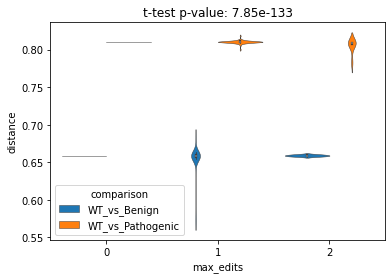

In [19]:
ESM.plot_paired_distances(dist_df=dist_df)

In [20]:
dist_df = hs.add_txid(dist_df, haplotypes)

Adding tx_id column


In [59]:
dist_df = hs.add_haplotype_freqs(df=dist_df, 
                                haplotypes=haplotypes,
                                force=True,
                                haplotype_col="haplotype")
dist_df.head()

Getting haplotype frequencies:   0%|          | 0/3 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations


Adding haplotype frequencies:   0%|          | 0/32 [00:00<?, ?it/s]

{'GBR': 'EUR', 'FIN': 'EUR', 'CHS': 'EAS', 'PUR': 'AMR', 'CDX': 'EAS', 'CLM': 'AMR', 'IBS': 'EUR', 'PEL': 'AMR', 'PJL': 'SAS', 'KHV': 'EAS', 'ACB': 'AFR', 'GWD': 'AFR', 'ESN': 'AFR', 'BEB': 'SAS', 'MSL': 'AFR', 'STU': 'SAS', 'ITU': 'SAS', 'CEU': 'EUR', 'YRI': 'AFR', 'CHB': 'EAS', 'JPT': 'EAS', 'LWK': 'AFR', 'ASW': 'AFR', 'MXL': 'AMR', 'TSI': 'EUR', 'GIH': 'SAS'}


,sample1,sample2,comparison,distance,haplotype,group1,group2,variants,protein_id,sample1_edits,...,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:YRI,top_pop,top_superpop,variant_id
7,"ENSP00000380150:530E>D,669T>M_WT:","ENSP00000380150:530E>D,669T>M_Benign:rs2301921",WT_vs_Benign,0.659002,"ENSP00000380150:530E>D,669T>M",WT:,Benign:rs2301921,rs2301921,ENSP00000380150,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:LWK,AFR,rs2301921
20,ENSP00000380150:544I>L_WT:,ENSP00000380150:544I>L_Benign:rs2301921,WT_vs_Benign,0.660211,ENSP00000380150:544I>L,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,NaN,NaN,NaN,NaN,NaN,0.004673,NaN,1000GENOMES:phase_3:IBS,EUR,rs2301921
21,ENSP00000380150:967R>H_WT:,ENSP00000380150:967R>H_Benign:rs2301921,WT_vs_Benign,0.658280,ENSP00000380150:967R>H,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:JPT,EAS,rs2301921
22,ENSP00000380150:902F>L_WT:,ENSP00000380150:902F>L_Benign:rs2301921,WT_vs_Benign,0.661951,ENSP00000380150:902F>L,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:CDX,EAS,rs2301921
23,ENSP00000380150:1032N>S_WT:,ENSP00000380150:1032N>S_Benign:rs2301921,WT_vs_Benign,0.664843,ENSP00000380150:1032N>S,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N/A,rs2301921


/grid/it/data/elzar/easybuild/software/SciPy-bundle/2021.05-foss-2021a/lib/python3.9/site-packages/scipy/stats/stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


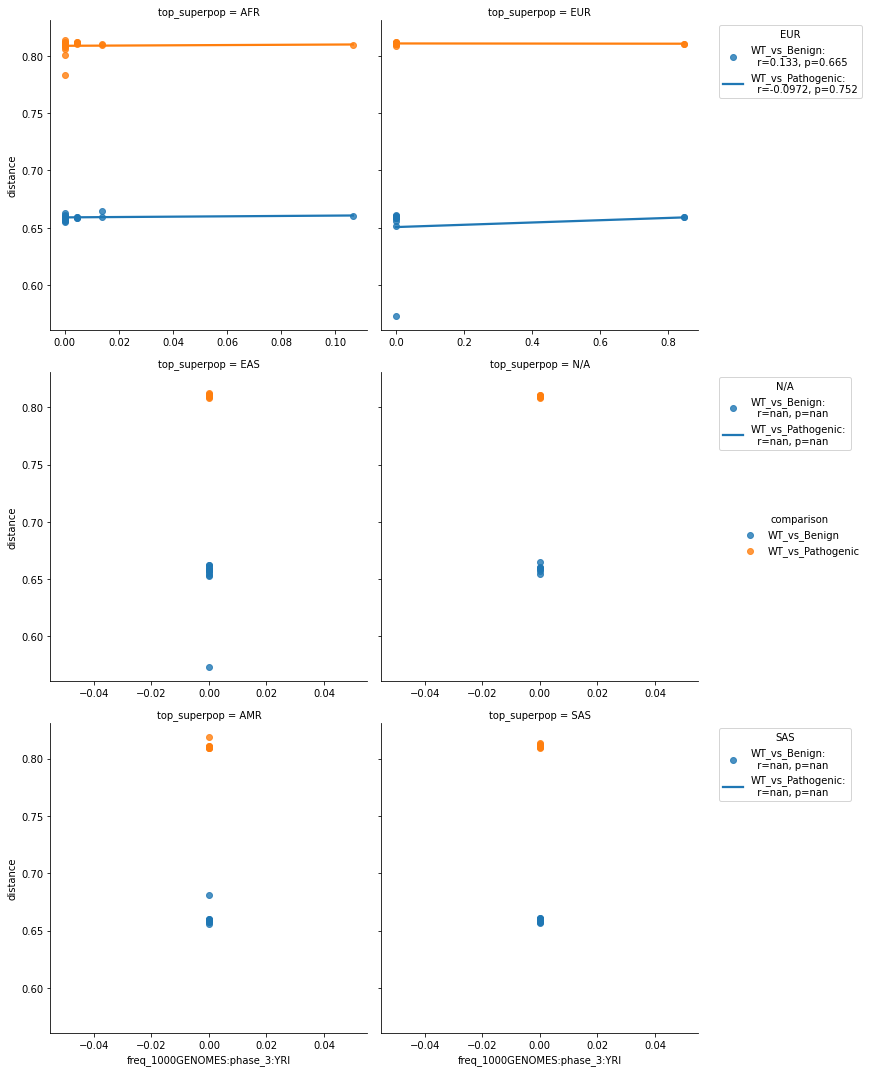

In [70]:
from scipy.stats import pearsonr
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

xvar = 'freq_1000GENOMES:phase_3:YRI'
yvar = 'distance'
dist_plot_df = dist_df.fillna(0)#.loc[distances_df[xvar].notna()]
# dist_plot_df[xvar] = dist_plot_df[xvar].apply(np.log)

# Calculate correlations for each group and superpop
correlations = {}
for superpop in dist_plot_df['top_superpop'].unique():
    correlations[superpop] = {}
    superpop_data = dist_plot_df[dist_plot_df['top_superpop'] == superpop]
    for group in superpop_data['comparison'].unique():
        group_data = superpop_data[superpop_data['comparison'] == group]
        r, p = pearsonr(group_data[xvar], group_data[yvar])
        correlations[superpop][group] = {'r': r, 'p': p}

# Create faceted plot
g = sns.lmplot(data=dist_plot_df,
           x=xvar,
           y='distance',
           hue='comparison',
           col='top_superpop',
           scatter=True,
           ci=None,
           col_wrap=2,
           facet_kws={'sharex': False}
           )

# Add correlation stats to each facet
for ax, superpop in zip(g.axes, correlations.keys()):
    legend_labels = []
    for group in correlations[superpop]:
        r = correlations[superpop][group]['r']
        p = correlations[superpop][group]['p']
        label = f"{group}:\n  r={r:.3}, p={p:.3}"
        legend_labels.append(label)
    ax.legend(title=f'{superpop}', labels=legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left')

In [63]:
variation = {id:hs.get_variation(id) for id in dist_df['variants'].unique()}
variation_df = pd.concat([hs.variation_to_dfs(x)['populations'].assign(variant_id=k) for k,x in variation.items()], axis=0)
variation_df['cohort'] = variation_df['population'].str.rsplit(':', n=1).str[0]
variation_df.loc[variation_df['cohort']=='1000GENOMES:phase_3']
# variation = hs.get_variation('rs1044136040')
# variation

,allele,frequency,allele_count,population,variant_id,cohort
0,A,0.87420,75411.0,gnomADe:sas,rs2301921,gnomADe
1,G,0.12580,10847.0,gnomADe:sas,rs2301921,gnomADe
2,G,0.02533,662.0,gnomADe:asj,rs2301921,gnomADe
3,A,0.97470,25474.0,gnomADe:asj,rs2301921,gnomADe
4,A,0.98150,1091430.0,gnomADe:nfe,rs2301921,gnomADe
...,...,...,...,...,...,...
20,T,1.00000,108.0,ALFA:SAMN10492704,rs387907351,ALFA
21,T,1.00000,6962.0,ALFA:SAMN10492695,rs387907351,ALFA
22,T,1.00000,84.0,ALFA:SAMN10492696,rs387907351,ALFA
23,T,1.00000,24.0,ALFA:SAMN10492701,rs387907351,ALFA


In [48]:
variation_df

,frequency,genotype,population,count,variant_id,cohort
0,0.032560,A|G,ESP6500:EA,140.0,rs2301921,ESP6500
1,0.967400,A|A,ESP6500:EA,4160.0,rs2301921,ESP6500
2,0.020430,G|G,ESP6500:AA,45.0,rs2301921,ESP6500
3,0.216100,A|G,ESP6500:AA,476.0,rs2301921,ESP6500
4,0.763500,A|A,ESP6500:AA,1682.0,rs2301921,ESP6500
...,...,...,...,...,...,...
98,0.193878,A|G,GGVP:GWJ,19.0,rs2301921,GGVP
99,0.806122,A|A,GGVP:GWJ,79.0,rs2301921,GGVP
100,0.201980,A|G,GGVP:ALL,102.0,rs2301921,GGVP
101,0.784158,A|A,GGVP:ALL,396.0,rs2301921,GGVP


In [39]:
# One haplotype
# WT_vs_Pathogenic dist x pathogenic variant freq x population 
hap = dist_df['haplotype'].unique()[0]
dist_df['variant_id'] = dist_df['variants'].str.split(',').str[0]
dist_df_merge = dist_df.loc[dist_df['group1'].str.startswith('WT')].melt(id_vars=[x for x in dist_df.columns if not x.startswith('freq_')], 
                                            value_vars=[x for x in dist_df.columns if x.startswith('freq_')],
                                            var_name='population',
                                            value_name='freq'
                                            ).assign(population=lambda x: x['population'].str.replace('freq_','')).merge(variation_df.loc[variation_df['cohort']=='1000GENOMES:phase_3'].rename(columns={'frequency':'variant_freq'}),
                                                    on=['variant_id','population'],
                                                    how='inner')
dist_df_merge




,sample1,sample2,comparison,distance,haplotype,group1,group2,variants,protein_id,sample1_edits,...,tx_id,top_pop,top_superpop,variant_id,population,freq,allele,variant_freq,allele_count,cohort
0,"ENSP00000380150:530E>D,669T>M_WT:","ENSP00000380150:530E>D,669T>M_Benign:rs2301921",WT_vs_Benign,0.659002,"ENSP00000380150:530E>D,669T>M",WT:,Benign:rs2301921,rs2301921,ENSP00000380150,2,...,ENST00000396946,1000GENOMES:phase_3:LWK,AFR,rs2301921,1000GENOMES:phase_3:ACB,NaN,A,0.833333,160.0,1000GENOMES:phase_3
1,"ENSP00000380150:530E>D,669T>M_WT:","ENSP00000380150:530E>D,669T>M_Benign:rs2301921",WT_vs_Benign,0.659002,"ENSP00000380150:530E>D,669T>M",WT:,Benign:rs2301921,rs2301921,ENSP00000380150,2,...,ENST00000396946,1000GENOMES:phase_3:LWK,AFR,rs2301921,1000GENOMES:phase_3:ACB,NaN,G,0.166667,32.0,1000GENOMES:phase_3
2,ENSP00000380150:544I>L_WT:,ENSP00000380150:544I>L_Benign:rs2301921,WT_vs_Benign,0.660211,ENSP00000380150:544I>L,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,ENST00000396946,1000GENOMES:phase_3:IBS,EUR,rs2301921,1000GENOMES:phase_3:ACB,NaN,A,0.833333,160.0,1000GENOMES:phase_3
3,ENSP00000380150:544I>L_WT:,ENSP00000380150:544I>L_Benign:rs2301921,WT_vs_Benign,0.660211,ENSP00000380150:544I>L,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,ENST00000396946,1000GENOMES:phase_3:IBS,EUR,rs2301921,1000GENOMES:phase_3:ACB,NaN,G,0.166667,32.0,1000GENOMES:phase_3
4,ENSP00000380150:967R>H_WT:,ENSP00000380150:967R>H_Benign:rs2301921,WT_vs_Benign,0.658280,ENSP00000380150:967R>H,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,ENST00000396946,1000GENOMES:phase_3:JPT,EAS,rs2301921,1000GENOMES:phase_3:ACB,NaN,A,0.833333,160.0,1000GENOMES:phase_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4783,ENSP00000380150:408R>L_WT:,ENSP00000380150:408R>L_Benign:rs2301921,WT_vs_Benign,0.659080,ENSP00000380150:408R>L,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,ENST00000396946,1000GENOMES:phase_3:YRI,AFR,rs2301921,1000GENOMES:phase_3:YRI,0.00463,A,0.842593,182.0,1000GENOMES:phase_3
4784,ENSP00000380150:392Q>R_WT:,ENSP00000380150:392Q>R_Benign:rs2301921,WT_vs_Benign,0.658603,ENSP00000380150:392Q>R,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,ENST00000396946,1000GENOMES:phase_3:KHV,EAS,rs2301921,1000GENOMES:phase_3:YRI,NaN,G,0.157407,34.0,1000GENOMES:phase_3
4785,ENSP00000380150:392Q>R_WT:,ENSP00000380150:392Q>R_Benign:rs2301921,WT_vs_Benign,0.658603,ENSP00000380150:392Q>R,WT:,Benign:rs2301921,rs2301921,ENSP00000380150,1,...,ENST00000396946,1000GENOMES:phase_3:KHV,EAS,rs2301921,1000GENOMES:phase_3:YRI,NaN,A,0.842593,182.0,1000GENOMES:phase_3
4786,"ENSP00000380150:123G>D,530E>D_WT:","ENSP00000380150:123G>D,530E>D_Benign:rs2301921",WT_vs_Benign,0.658039,"ENSP00000380150:123G>D,530E>D",WT:,Benign:rs2301921,rs2301921,ENSP00000380150,2,...,ENST00000396946,1000GENOMES:phase_3:LWK,AFR,rs2301921,1000GENOMES:phase_3:YRI,NaN,G,0.157407,34.0,1000GENOMES:phase_3


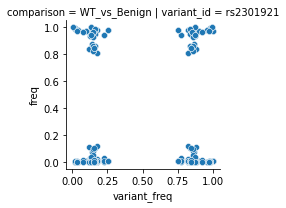

In [44]:
g = sns.FacetGrid(dist_df_merge, col="variant_id",  row="comparison")
g.map(sns.scatterplot, 'variant_freq', 'freq')



### Infer the "optimal" protein haplotype
- Can we compute the reverse trajectory of pathogenic --> WT and infer the "optimal" protein haplotype?
- In other words, in a population of healthy and unhealthy individuals, which protein haplotype (observed or computationally inferred) is evolution pointing towards?
- This is not necessarily the most common haplotype, as other evolutionary forces may be at play (e.g. drift, founder effects, selection for traits that are no longer beneficial in modern times).
